# Анализ погодных данных Москвы и Санкт-Петербурга, 2015–2025

**Цель исследования** — изучить температурный режим и осадки двух городов,
выявить тренд потепления и проверить статистически, отличается ли средняя
температура начала и конца периода.

**Задачи исследования**

1. Загрузить реальные данные из открытого API Open-Meteo
2. Провести очистку и подготовку данных
3. Провести исследовательский анализ: температура, осадки, рекорды
4. Оценить тренд изменения температуры по годам
5. Сравнить Москву и Санкт-Петербург
6. Проверить гипотезы с помощью корреляции и t-теста

**Источник данных:** [Open-Meteo Archive API](https://open-meteo.com/en/docs/historical-weather-api) —
ретроспективные данные ERA5, ежедневные показатели, без API-ключей.

**Использованные библиотеки:** pandas, numpy, matplotlib, seaborn, scipy, requests

In [1]:
%matplotlib inline

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")
pd.options.display.float_format = lambda x: f"{x:.2f}"

DATA_DIR = Path("data")
ASSETS_DIR = Path("assets")
DATA_DIR.mkdir(exist_ok=True)
ASSETS_DIR.mkdir(exist_ok=True)

## 1. Загрузка данных из интернета

Данные берутся из Open-Meteo Archive API. Если файл уже скачан — читаем его,
иначе запрашиваем данные у API и сохраняем в `data/`. Период: 2015-01-01 — 2025-12-31.

In [2]:
API_URL = "https://archive-api.open-meteo.com/v1/archive"
DAILY_VARS = (
    "temperature_2m_mean,temperature_2m_max,temperature_2m_min,"
    "precipitation_sum,snowfall_sum"
)
CITIES = {
    "moscow": {"lat": 55.75, "lon": 37.62, "label": "Москва"},
    "spb": {"lat": 59.93, "lon": 30.31, "label": "Санкт-Петербург"},
}


def fetch_daily(lat, lon, start="2015-01-01", end="2025-12-31"):
    response = requests.get(
        API_URL,
        params={
            "latitude": lat,
            "longitude": lon,
            "start_date": start,
            "end_date": end,
            "daily": DAILY_VARS,
            "timezone": "Europe/Moscow",
        },
        timeout=60,
    )
    response.raise_for_status()
    return pd.DataFrame(response.json()["daily"])


frames = []
for city, info in CITIES.items():
    path = DATA_DIR / f"{city}_daily.csv"
    if path.exists():
        df = pd.read_csv(path, parse_dates=["time"])
        source = "файл"
    else:
        df = fetch_daily(info["lat"], info["lon"])
        df.insert(0, "city", city)
        df.to_csv(path, index=False)
        source = "API"
    frames.append(df)
    print(f"{info['label']:<17} {source:>5}: {path}  строк={len(df)}")

weather = pd.concat(frames, ignore_index=True)

Москва             файл: data\moscow_daily.csv  строк=4018
Санкт-Петербург    файл: data\spb_daily.csv  строк=4018


## 2. Обзор данных

In [3]:
weather.head()

,city,time,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,snowfall_sum
0,moscow,2015-01-01,-1.10,1.00,-6.30,0.50,0.49
1,moscow,2015-01-02,0.90,1.50,0.30,2.80,1.82
2,moscow,2015-01-03,1.10,2.40,-0.10,0.30,0.21
3,moscow,2015-01-04,-0.60,0.00,-1.50,2.50,2.24
4,moscow,2015-01-05,-10.50,-1.80,-16.80,0.40,0.56


In [4]:
weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 8036 entries, 0 to 8035
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   city                 8036 non-null   str           
 1   time                 8036 non-null   datetime64[us]
 2   temperature_2m_mean  8036 non-null   float64       
 3   temperature_2m_max   8036 non-null   float64       
 4   temperature_2m_min   8036 non-null   float64       
 5   precipitation_sum    8036 non-null   float64       
 6   snowfall_sum         8036 non-null   float64       
dtypes: datetime64[us](1), float64(5), str(1)
memory usage: 474.9 KB


In [5]:
weather.describe()

,time,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,snowfall_sum
count,8036,8036.00,8036.00,8036.00,8036.00,8036.00
mean,2020-07-01 12:00:00,6.42,9.69,3.01,1.90,0.33
min,2015-01-01 00:00:00,-29.80,-26.60,-31.40,0.00,0.00
25%,2017-10-01 00:00:00,-0.60,1.30,-3.00,0.00,0.00
50%,2020-07-01 12:00:00,5.70,9.00,2.60,0.40,0.00
75%,2023-04-02 00:00:00,15.20,19.00,10.90,2.30,0.00
max,2025-12-31 00:00:00,29.00,35.10,23.70,58.00,13.79
std,NaN,9.84,10.67,9.29,3.52,0.98


In [6]:
# Пропуски и дубликаты
print("Пропуски по столбцам:")
print(weather.isna().sum(), "\n")
print("Полных дубликатов строк:", weather.duplicated().sum())
print("Дубликатов (город, дата):", weather.duplicated(subset=["city", "time"]).sum())

Пропуски по столбцам:
city                   0
time                   0
temperature_2m_mean    0
temperature_2m_max     0
temperature_2m_min     0
precipitation_sum      0
snowfall_sum           0
dtype: int64 

Полных дубликатов строк: 0
Дубликатов (город, дата): 0


## 3. Подготовка данных

Переименуем столбцы, добавим названия городов и производные признаки
(год, месяц), проверим полноту периода.

In [7]:
weather = weather.rename(columns={
    "time": "date",
    "temperature_2m_mean": "temp_mean",
    "temperature_2m_max": "temp_max",
    "temperature_2m_min": "temp_min",
    "precipitation_sum": "precipitation",
    "snowfall_sum": "snowfall",
})
weather["city"] = weather["city"].map({k: v["label"] for k, v in CITIES.items()})
weather["date"] = pd.to_datetime(weather["date"])
weather["year"] = weather["date"].dt.year
weather["month"] = weather["date"].dt.month
weather = weather.sort_values(["city", "date"]).reset_index(drop=True)

print("Период данных:", weather["date"].min().date(), "—", weather["date"].max().date())
print("Всего строк:", len(weather))
print()
print("Строк по городам:")
print(weather.groupby("city").agg(
    first=("date", "min"),
    last=("date", "max"),
    days=("date", "count"),
))

Период данных: 2015-01-01 — 2025-12-31
Всего строк: 8036

Строк по городам:
                     first       last  days
city                                       
Москва          2015-01-01 2025-12-31  4018
Санкт-Петербург 2015-01-01 2025-12-31  4018


In [8]:
moscow = weather[weather["city"] == "Москва"].copy()
spb = weather[weather["city"] == "Санкт-Петербург"].copy()
moscow.head()

,city,date,temp_mean,temp_max,temp_min,precipitation,snowfall,year,month
0,Москва,2015-01-01,-1.10,1.00,-6.30,0.50,0.49,2015,1
1,Москва,2015-01-02,0.90,1.50,0.30,2.80,1.82,2015,1
2,Москва,2015-01-03,1.10,2.40,-0.10,0.30,0.21,2015,1
3,Москва,2015-01-04,-0.60,0.00,-1.50,2.50,2.24,2015,1
4,Москва,2015-01-05,-10.50,-1.80,-16.80,0.40,0.56,2015,1


## 4. Температура: месячный профиль и рекорды

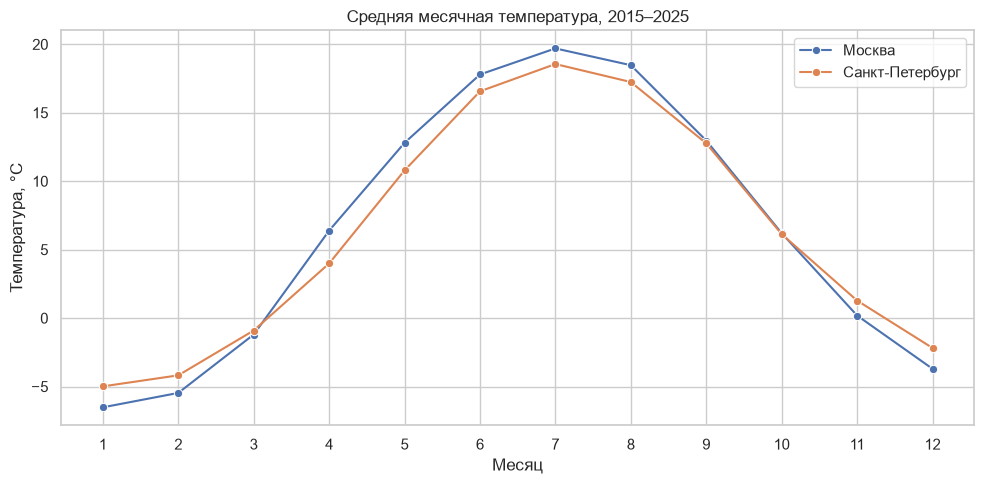

In [9]:
monthly_profile = (
    weather.groupby(["city", "month"], as_index=False)["temp_mean"].mean()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=monthly_profile, x="month", y="temp_mean",
             hue="city", marker="o", ax=ax)
ax.set_title("Средняя месячная температура, 2015–2025")
ax.set_xlabel("Месяц")
ax.set_ylabel("Температура, °C")
ax.set_xticks(range(1, 13))
ax.legend(title="")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "monthly_profile.png", dpi=120)
plt.show()

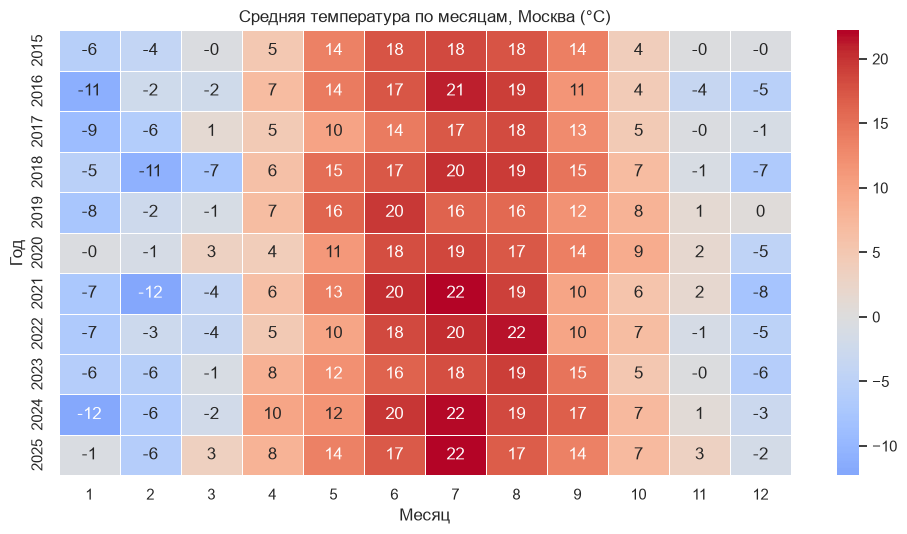

In [10]:
# Тепловая карта: год x месяц (Москва)
pivot = moscow.pivot_table(index="year", columns="month",
                           values="temp_mean", aggfunc="mean")

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax)
ax.set_title("Средняя температура по месяцам, Москва (°C)")
ax.set_xlabel("Месяц")
ax.set_ylabel("Год")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "heatmap_moscow.png", dpi=120)
plt.show()

In [11]:
print("Топ-5 самых жарких дней в Москве:")
display(moscow.nlargest(5, "temp_max")[["date", "temp_max", "precipitation"]])

print("Топ-5 самых холодных дней в Москве:")
display(moscow.nsmallest(5, "temp_min")[["date", "temp_min", "snowfall"]])

Топ-5 самых жарких дней в Москве:


,date,temp_max,precipitation
3844,2025-07-11,35.10,0.00
3843,2025-07-10,33.50,0.00
2365,2021-06-23,33.40,0.00
2366,2021-06-24,33.20,0.00
3845,2025-07-12,33.20,0.60


Топ-5 самых холодных дней в Москве:


,date,temp_min,snowfall
738,2017-01-08,-31.10,0.00
3299,2024-01-13,-31.00,0.00
739,2017-01-09,-30.40,0.00
737,2017-01-07,-29.80,0.00
3290,2024-01-04,-29.80,0.00


## 5. Осадки

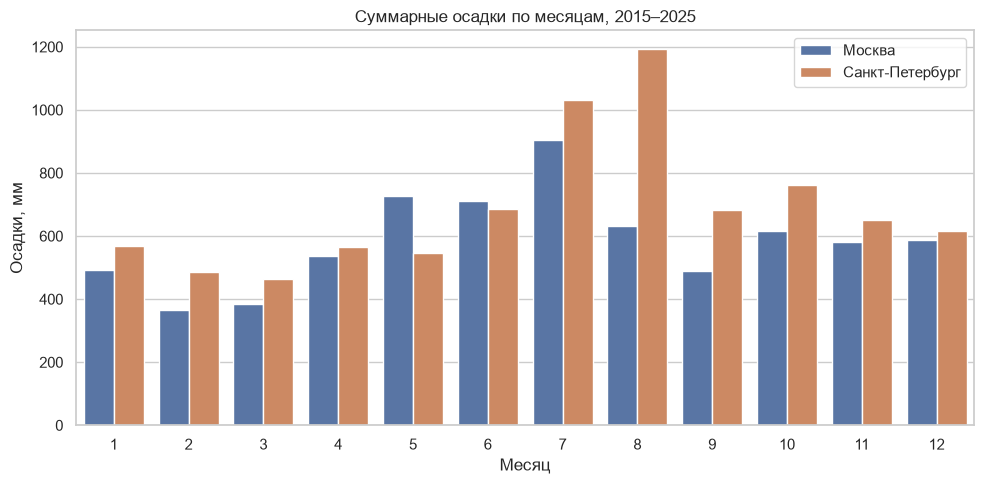

In [12]:
monthly_precip = (
    weather.groupby(["city", "month"], as_index=False)["precipitation"].sum()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=monthly_precip, x="month", y="precipitation",
            hue="city", ax=ax)
ax.set_title("Суммарные осадки по месяцам, 2015–2025")
ax.set_xlabel("Месяц")
ax.set_ylabel("Осадки, мм")
ax.legend(title="")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "monthly_precipitation.png", dpi=120)
plt.show()

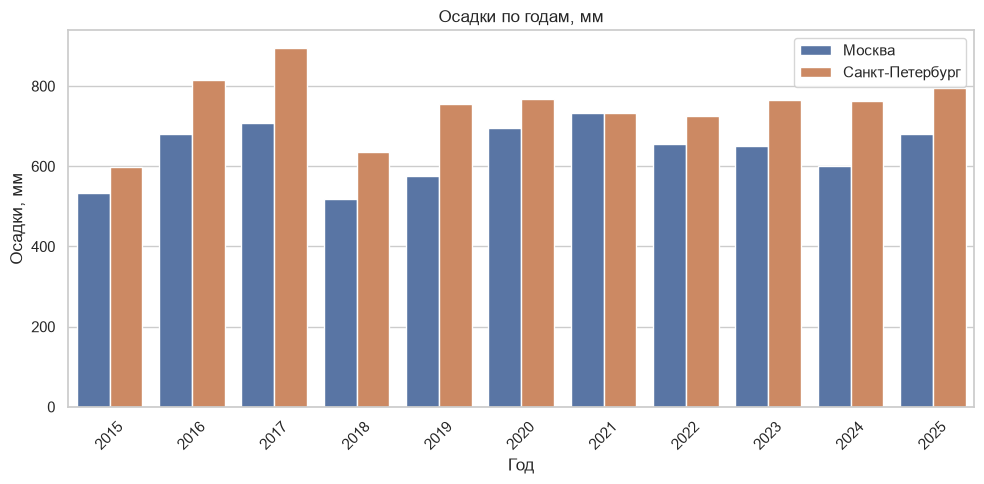

In [13]:
yearly_precip = (
    weather.groupby(["city", "year"], as_index=False)["precipitation"].sum()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=yearly_precip, x="year", y="precipitation",
            hue="city", ax=ax)
ax.set_title("Осадки по годам, мм")
ax.set_xlabel("Год")
ax.set_ylabel("Осадки, мм")
ax.legend(title="")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "yearly_precipitation.png", dpi=120)
plt.show()

In [14]:
print("Топ-5 самых дождливых дней в Москве:")
display(moscow.nlargest(5, "precipitation")[["date", "precipitation", "temp_mean"]])

Топ-5 самых дождливых дней в Москве:


,date,precipitation,temp_mean
592,2016-08-15,58.00,14.60
3449,2024-06-11,33.00,20.90
1977,2020-05-31,31.70,11.10
3854,2025-07-21,31.20,18.90
177,2015-06-27,28.80,17.70


## 6. Тренд потепления

Считаем аномалию — отклонение среднегодовой температуры от среднего за весь период.

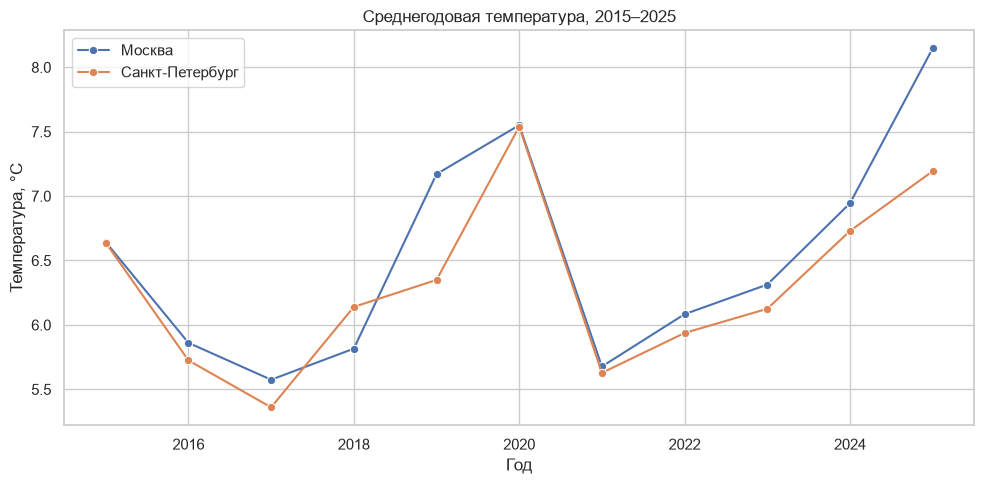

In [15]:
yearly_temp = weather.groupby(["city", "year"], as_index=False)["temp_mean"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=yearly_temp, x="year", y="temp_mean",
             hue="city", marker="o", ax=ax)
ax.set_title("Среднегодовая температура, 2015–2025")
ax.set_xlabel("Год")
ax.set_ylabel("Температура, °C")
ax.legend(title="")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "yearly_temperature.png", dpi=120)
plt.show()

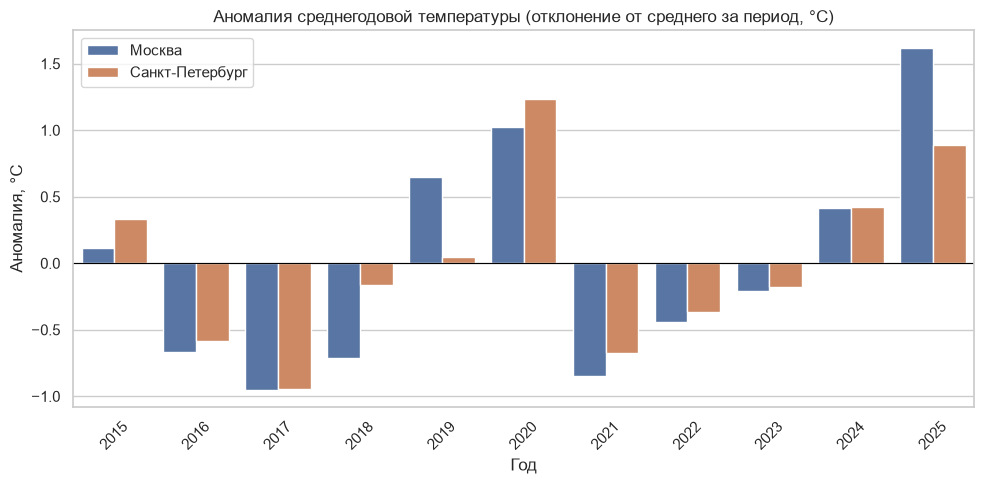

In [16]:
anomaly = yearly_temp.copy()
anomaly["anomaly"] = anomaly["temp_mean"] - anomaly.groupby("city")["temp_mean"].transform("mean")

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=anomaly, x="year", y="anomaly", hue="city", ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Аномалия среднегодовой температуры (отклонение от среднего за период, °C)")
ax.set_xlabel("Год")
ax.set_ylabel("Аномалия, °C")
ax.legend(title="")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "temperature_anomaly.png", dpi=120)
plt.show()

In [17]:
for city, group in anomaly.groupby("city"):
    early = group[group["year"].between(2015, 2019)]["temp_mean"]
    late = group[group["year"].between(2021, 2025)]["temp_mean"]
    print(f"{city}:")
    print(f"  2015–2019: {early.mean():.2f} °C")
    print(f"  2021–2025: {late.mean():.2f} °C")
    print(f"  разница:   {late.mean() - early.mean():+.2f} °C\n")

Москва:
  2015–2019: 6.21 °C
  2021–2025: 6.63 °C
  разница:   +0.42 °C

Санкт-Петербург:
  2015–2019: 6.04 °C
  2021–2025: 6.32 °C
  разница:   +0.28 °C



## 7. Статистические проверки

### 7.1. Корреляция температуры и осадков

Нулевая гипотеза H₀: между средней дневной температурой и суммой осадков
нет линейной связи (коэффициент Пирсона равен нулю).

Коэффициент Пирсона: r = 0.074
p-value: 3.02e-06


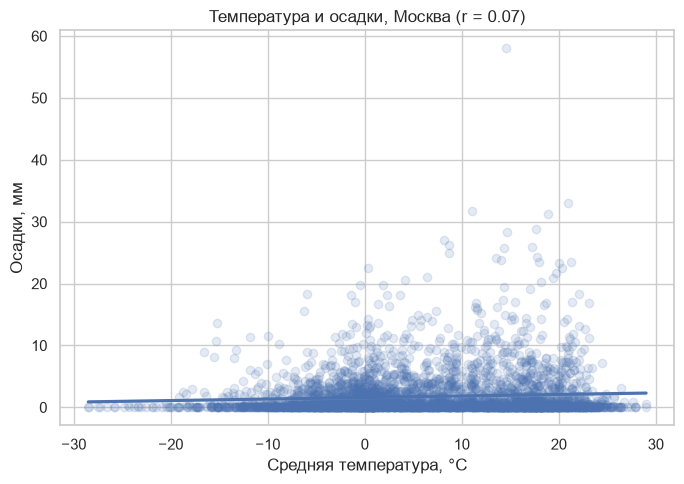

In [18]:
sub = moscow[["temp_mean", "precipitation"]]
r, p_value = stats.pearsonr(sub["temp_mean"], sub["precipitation"])
print(f"Коэффициент Пирсона: r = {r:.3f}")
print(f"p-value: {p_value:.3g}")

fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(data=sub, x="temp_mean", y="precipitation",
            scatter_kws={"alpha": 0.15}, ax=ax)
ax.set_title(f"Температура и осадки, Москва (r = {r:.2f})")
ax.set_xlabel("Средняя температура, °C")
ax.set_ylabel("Осадки, мм")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "correlation_temp_precip.png", dpi=120)
plt.show()

**Интерпретация:** p-value меньше 0.05 — нулевая гипотеза отвергается, связь
статистически значима. Однако коэффициент r = 0.074 крайне мал: из-за большого
числа наблюдений (более 4000 дней) даже слабая связь становится значимой.
Практически температура и объём осадков за один день почти не связаны.

### 7.2. t-тест: изменилась ли средняя температура?

Сравним две непересекающиеся пятилетки: начало периода (2015–2019)
и конец периода (2021–2025).

- H₀: средняя температура в двух периодах одинакова
- H₁: средние различаются
- α = 0.05

Используем тест Уэлча (без предположения об одинаковой дисперсии).

In [19]:
early = moscow[moscow["year"].between(2015, 2019)]["temp_mean"]
late = moscow[moscow["year"].between(2021, 2025)]["temp_mean"]

t_stat, p_value = stats.ttest_ind(late, early, equal_var=False)

print(f"2015–2019: n = {len(early)}, средняя = {early.mean():.2f} °C, дисперсия = {early.var():.2f}")
print(f"2021–2025: n = {len(late)},  средняя = {late.mean():.2f} °C, дисперсия = {late.var():.2f}")
print(f"Разница средних: {late.mean() - early.mean():+.2f} °C")
print(f"t-статистика: {t_stat:.2f}")
print(f"p-value: {p_value:.3g}")

alpha = 0.05
print("\nВывод:", "H₀ отвергается — различие значимо" if p_value < alpha
      else "H₀ не отвергается — различие статистически незначимо")

2015–2019: n = 1826, средняя = 6.21 °C, дисперсия = 105.04
2021–2025: n = 1826,  средняя = 6.63 °C, дисперсия = 116.78
Разница средних: +0.42 °C
t-статистика: 1.21
p-value: 0.228

Вывод: H₀ не отвергается — различие статистически незначимо


## 8. Выводы

1. Загружены реальные данные Open-Meteo за 11 лет (2015–2025) по двум городам,
   пропусков и дубликатов нет.
2. Москва теплее Санкт-Петербурга в среднем на ~2 °C в течение всего года;
   профили температур у городов совпадают по форме.
3. Максимум осадков приходится на летние месяцы, зимой осадков заметно меньше.
4. Среднегодовая температура выросла: Москва +0.42 °C, Санкт-Петербург +0.28 °C
   (2015–2019 против 2021–2025).
5. **T-тест Уэлча не подтвердил значимость этого роста** (p = 0.228 > 0.05):
   за 11 лет недостаточно данных, чтобы отделить тренд от естественной
   изменчивости климата. Для подтверждения потепления нужен более длинный ряд.
6. Корреляция температуры и осадков в Москве статистически значима (p < 0.05),
   но практически связь очень слабая (r = 0.074).
7. **Главный вывод для портфолио:** статистически значимое отличие ≠ реальный
   эффект. Числа в данных есть, а гипотеза не подтвердилась — это тоже результат.